# EDA: Croissant & Danish Sales

Structured exploration of the processed bakery data before modeling.

**Workflow**: Load & Inspect -> Summary Stats -> Visualize Patterns -> Data Quality -> Deep Dives -> Findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)

## Step 1: Load & Inspect

In [2]:
df = pd.read_csv('../data/processed/danish_croissant_data.csv', parse_dates=['date'])

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Dtypes:\n{df.dtypes}")
print(f"\nDate range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Products: {df['item'].unique()}")
print(f"\nRows per product:")
print(df['item'].value_counts())

Shape: (1902, 3)
Columns: ['date', 'item', 'quantity']
Dtypes:
date        datetime64[ns]
item                object
quantity             int64
dtype: object

Date range: 2021-05-13 to 2025-10-30
Products: ['Croissant' 'Danish']

Rows per product:
item
Croissant    966
Danish       936
Name: count, dtype: int64


In [3]:
print("=== First 10 rows ===")
display(df.head(10))
print("\n=== Last 10 rows ===")
display(df.tail(10))

=== First 10 rows ===


,date,item,quantity
0,2021-05-13,Croissant,42
1,2021-05-13,Danish,27
2,2021-05-14,Croissant,61
3,2021-05-14,Danish,27
4,2021-05-15,Croissant,100
5,2021-05-15,Danish,59
6,2021-05-16,Croissant,53
7,2021-05-16,Danish,28
8,2021-05-18,Croissant,21
9,2021-05-18,Danish,25



=== Last 10 rows ===


,date,item,quantity
1892,2025-10-23,Croissant,36
1893,2025-10-23,Danish,14
1894,2025-10-24,Croissant,31
1895,2025-10-24,Danish,24
1896,2025-10-25,Croissant,79
1897,2025-10-25,Danish,42
1898,2025-10-26,Croissant,37
1899,2025-10-26,Danish,13
1900,2025-10-30,Croissant,17
1901,2025-10-30,Danish,16


## Step 2: Summary Statistics

**Question for you**: Before looking at the numbers, which product do you think sells more — Croissant or Danish? And which do you think is more *predictable* (less variable day-to-day)?

In [4]:
summary = df.groupby('item')['quantity'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
    max='max'
).round(2)

summary['cv'] = (summary['std'] / summary['mean']).round(3)
summary['iqr'] = summary['q75'] - summary['q25']

print("Per-product summary statistics:")
print("(cv = coefficient of variation = std/mean — lower means more predictable)\n")
display(summary)

Per-product summary statistics:
(cv = coefficient of variation = std/mean — lower means more predictable)



,count,mean,median,std,min,q25,q75,max,cv,iqr
item,,,,,,,,,,
Croissant,966,52.95,50.0,24.53,1,35.0,68.0,145,0.463,33.0
Danish,936,29.55,27.0,15.17,1,18.0,39.0,84,0.513,21.0


In [5]:
# Temporal coverage — how many unique dates per product?
date_counts = df.groupby('item')['date'].agg(['nunique', 'min', 'max'])
date_counts.columns = ['unique_days', 'first_date', 'last_date']
date_counts['span_days'] = (date_counts['last_date'] - date_counts['first_date']).dt.days
date_counts['coverage_pct'] = (date_counts['unique_days'] / date_counts['span_days'] * 100).round(1)

print("Temporal coverage per product:")
display(date_counts)

Temporal coverage per product:


,unique_days,first_date,last_date,span_days,coverage_pct
item,,,,,
Croissant,966,2021-05-13,2025-10-30,1631,59.2
Danish,936,2021-05-13,2025-10-30,1631,57.4


## Step 3: Visualize Patterns

### 3a. Daily Sales Time Series

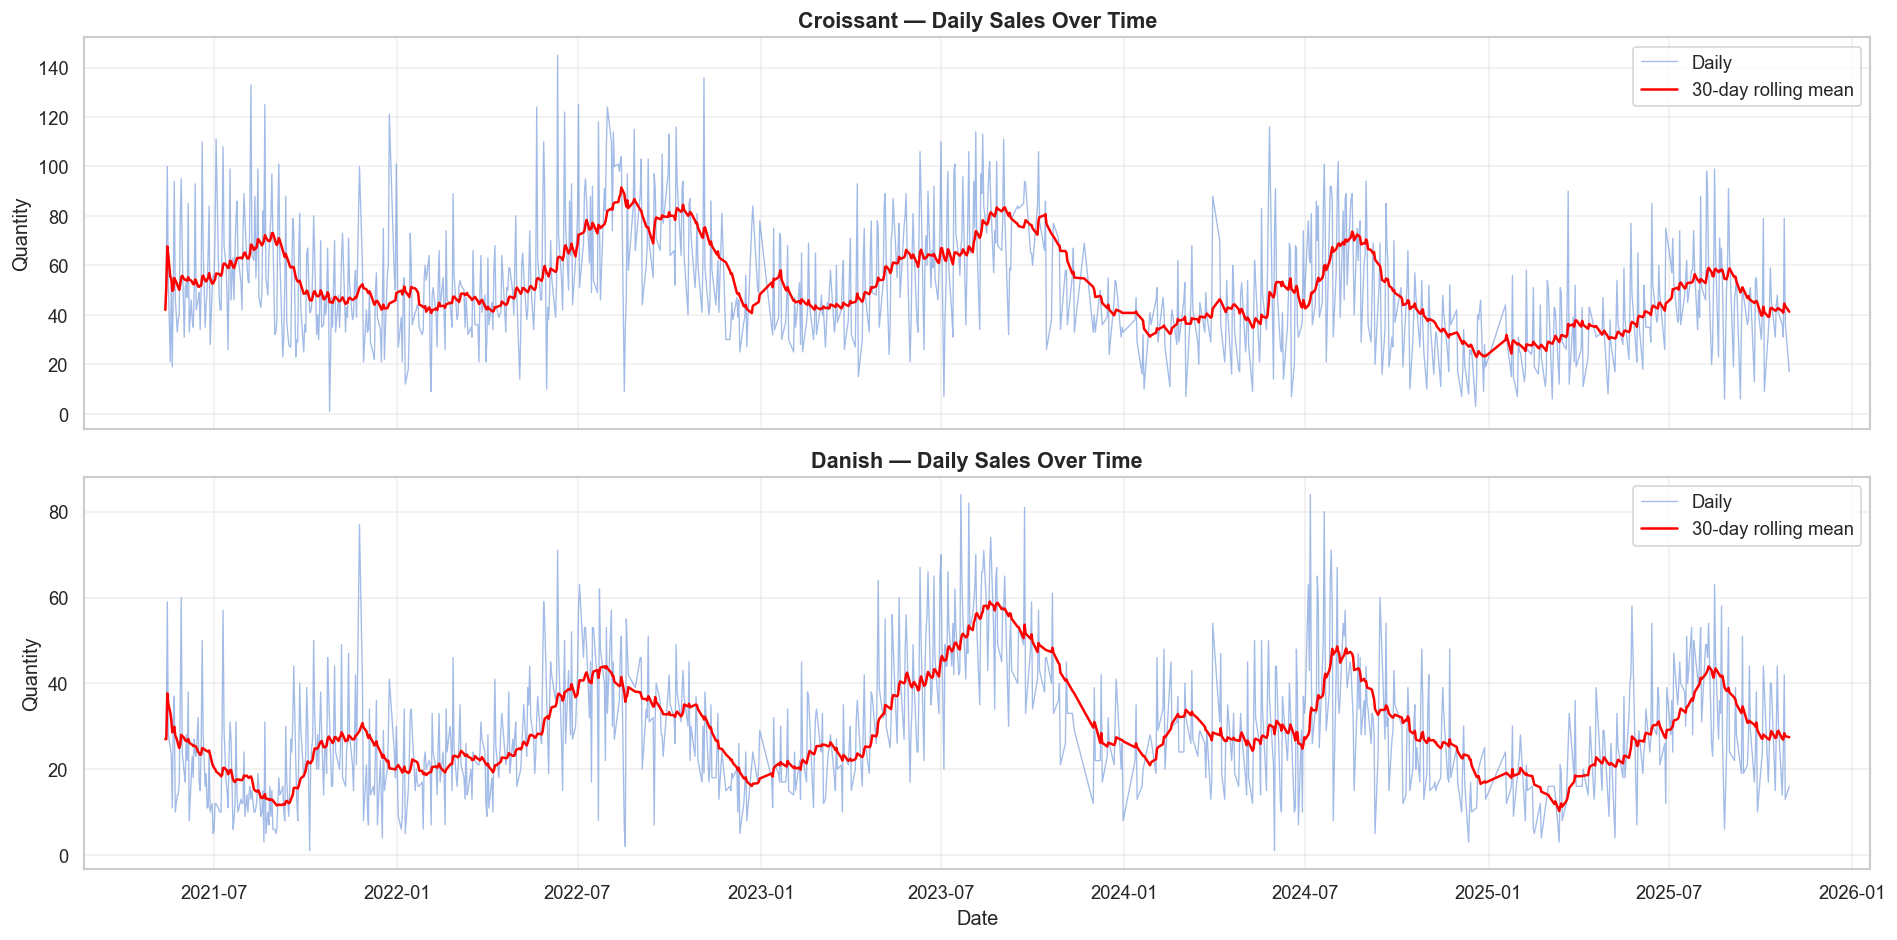


What patterns jump out? Do you see any regular rhythms, trends, or sudden changes?


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for idx, item in enumerate(['Croissant', 'Danish']):
    item_df = df[df['item'] == item].sort_values('date')
    axes[idx].plot(item_df['date'], item_df['quantity'], alpha=0.5, linewidth=0.8, label='Daily')
    # 30-day rolling mean (operational days)
    rolling = item_df.set_index('date')['quantity'].rolling('30D').mean()
    axes[idx].plot(rolling.index, rolling.values, color='red', linewidth=1.5, label='30-day rolling mean')
    axes[idx].set_title(f'{item} — Daily Sales Over Time', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Quantity')
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3)

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../reports/figures/eda_time_series.png', bbox_inches='tight')
plt.show()
print("\nWhat patterns jump out? Do you see any regular rhythms, trends, or sudden changes?")

### 3b. Day-of-Week Pattern

Day-of-week is typically the strongest predictor in bakery sales. Let's see if that holds here.

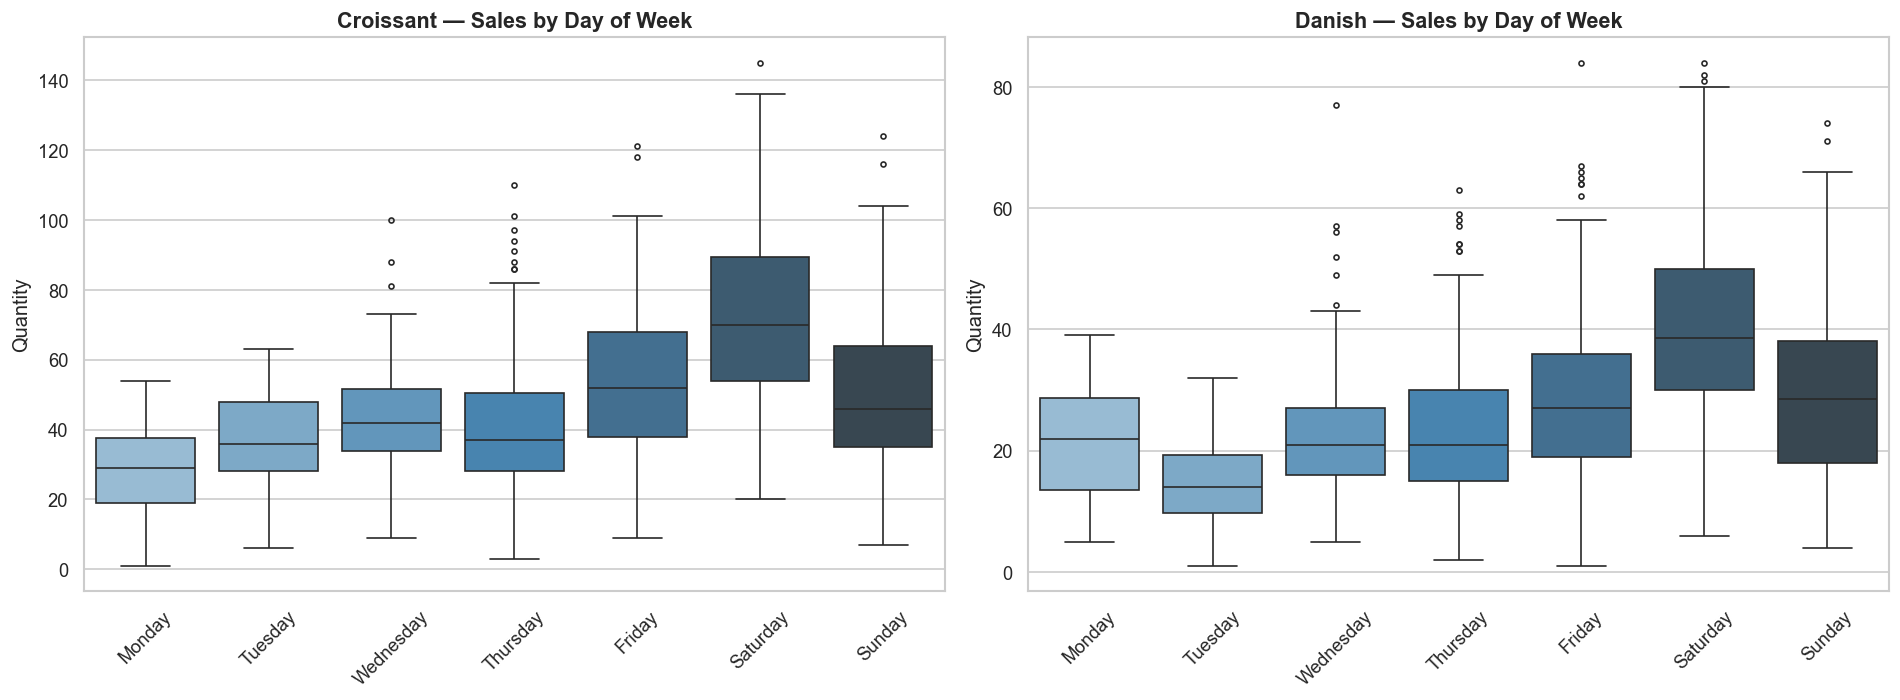


Mean quantity by day of week:


item,Croissant,Danish
day_name,,
Monday,27.6,21.6
Tuesday,37.4,14.6
Wednesday,44.0,23.4
Thursday,40.9,23.8
Friday,53.6,28.4
Saturday,72.6,39.9
Sunday,49.4,29.3



Which day is busiest for each product? Does the pattern differ between Croissant and Danish?


In [7]:
df['day_of_week'] = df['date'].dt.dayofweek
df['day_name'] = df['date'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, item in enumerate(['Croissant', 'Danish']):
    item_df = df[df['item'] == item]
    sns.boxplot(data=item_df, x='day_name', y='quantity', order=day_order, ax=axes[idx],
                palette='Blues_d', fliersize=3)
    axes[idx].set_title(f'{item} — Sales by Day of Week', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Quantity')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/eda_day_of_week.png', bbox_inches='tight')
plt.show()

# Numeric summary
print("\nMean quantity by day of week:")
dow_summary = df.pivot_table(values='quantity', index='day_name', columns='item', aggfunc='mean').round(1)
dow_summary = dow_summary.reindex(day_order)
display(dow_summary)

print("\nWhich day is busiest for each product? Does the pattern differ between Croissant and Danish?")

In [8]:
# Check which days the bakery actually operates
print("Number of data points per day of week (across all data):")
dow_counts = df.groupby(['item', 'day_name']).size().unstack(level=0)
dow_counts = dow_counts.reindex(day_order)
display(dow_counts)

print("\nDays with very few or zero entries likely mean the bakery is closed.")

Number of data points per day of week (across all data):


item,Croissant,Danish
day_name,,
Monday,19,18
Tuesday,25,24
Wednesday,79,76
Thursday,183,171
Friday,218,211
Saturday,224,220
Sunday,218,216



Days with very few or zero entries likely mean the bakery is closed.


### 3c. Monthly / Seasonal Pattern

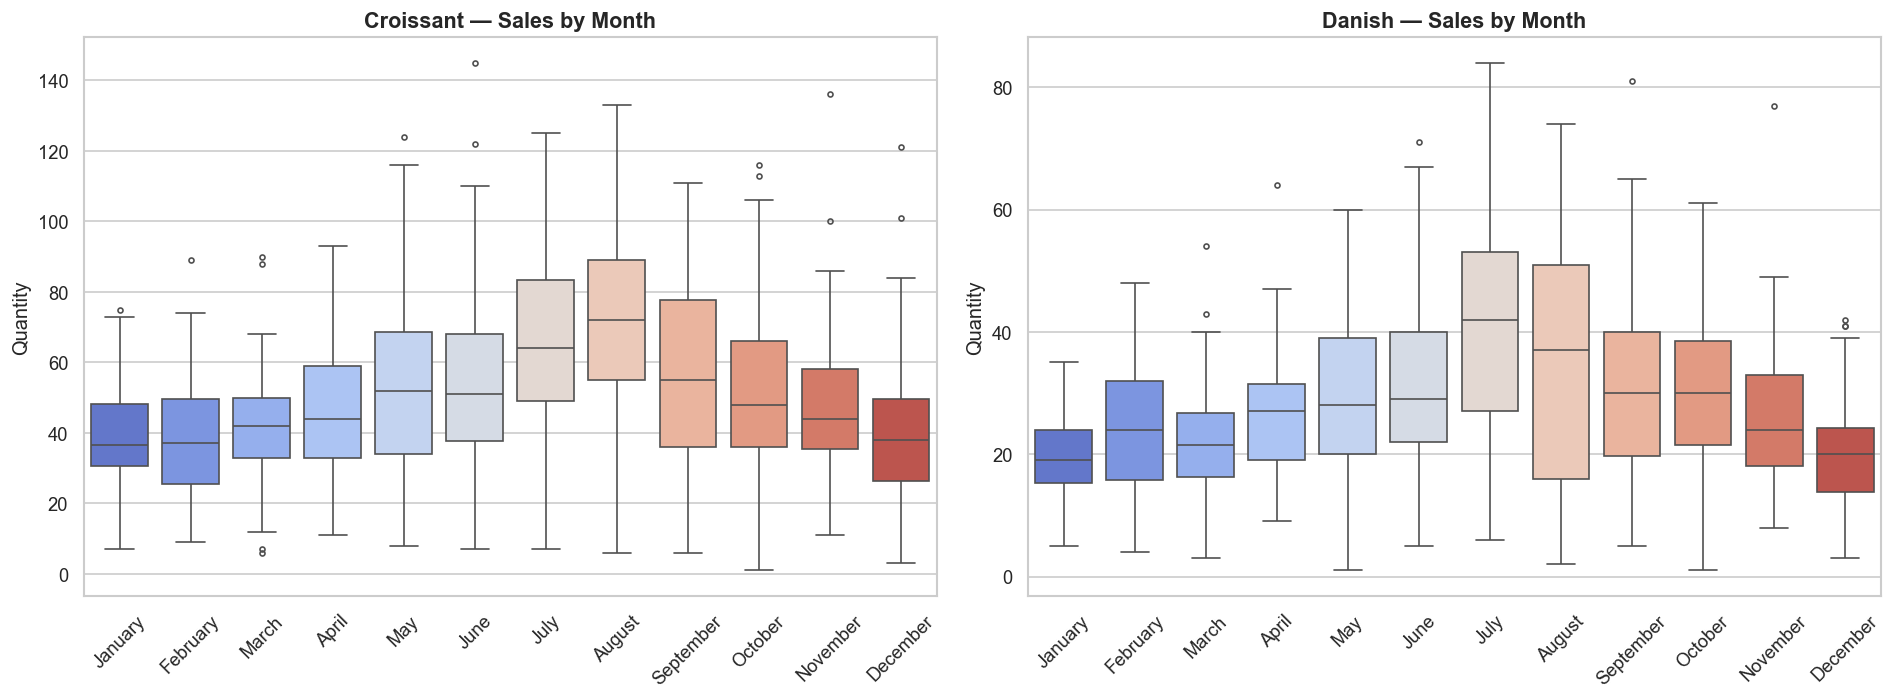


Mean quantity by month:


item,Croissant,Danish
month_name,,
January,39.2,19.9
February,38.6,24.1
March,41.9,22.5
April,45.9,26.5
May,52.5,30.7
June,55.1,31.4
July,66.9,39.8
August,71.8,36.0
September,56.6,30.9


In [9]:
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, item in enumerate(['Croissant', 'Danish']):
    item_df = df[df['item'] == item]
    sns.boxplot(data=item_df, x='month_name', y='quantity', order=month_order, ax=axes[idx],
                palette='coolwarm', fliersize=3)
    axes[idx].set_title(f'{item} — Sales by Month', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Quantity')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/eda_monthly_pattern.png', bbox_inches='tight')
plt.show()

print("\nMean quantity by month:")
monthly_summary = df.pivot_table(values='quantity', index='month_name', columns='item', aggfunc='mean').round(1)
monthly_summary = monthly_summary.reindex(month_order)
display(monthly_summary)

### 3d. Year-over-Year Comparison

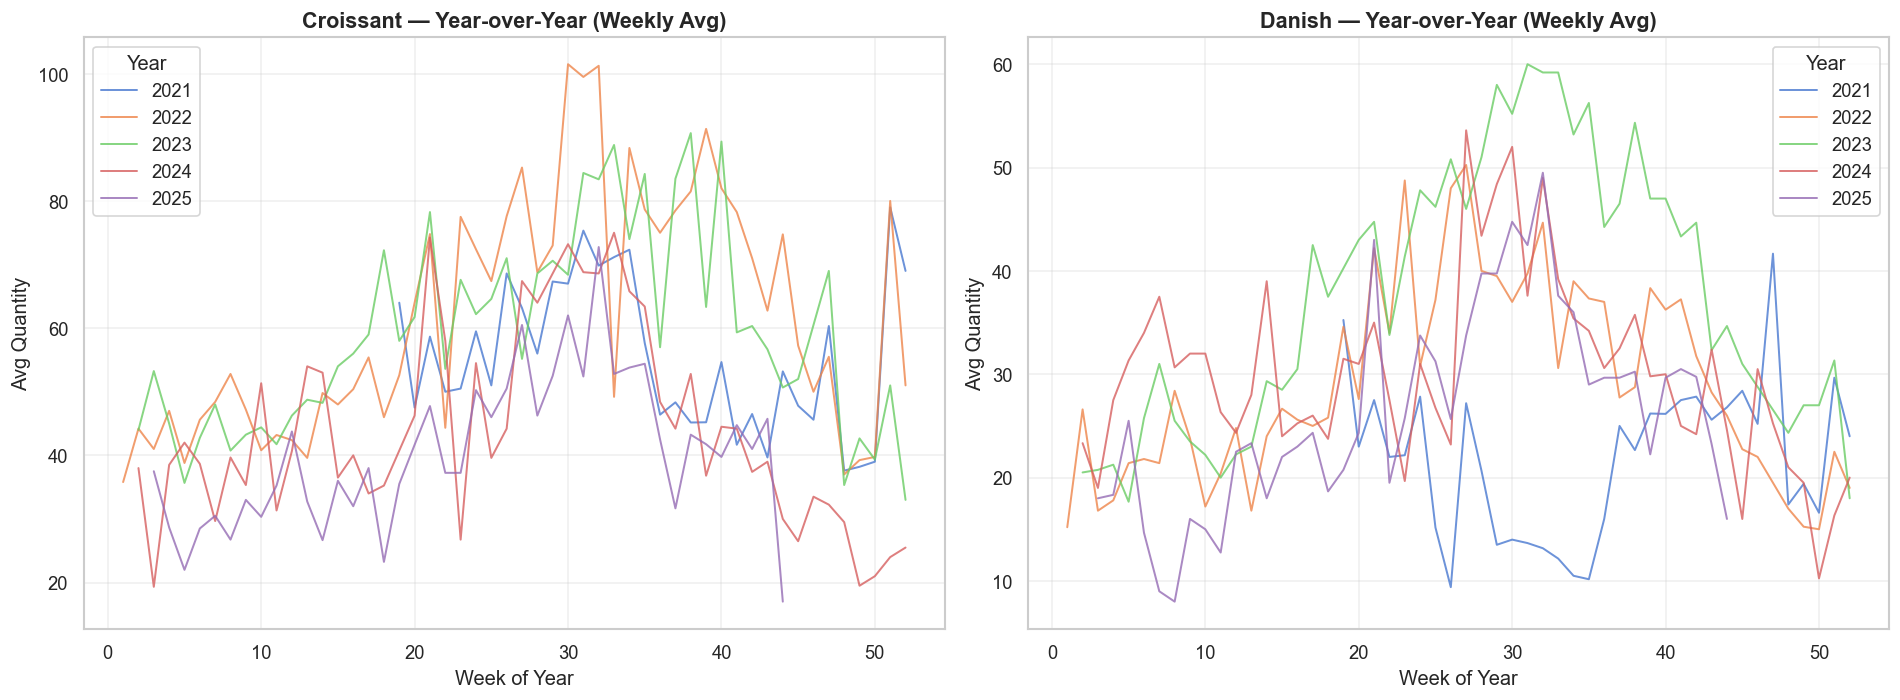


Annual summary:


mean              sum            count       
item Croissant Danish Croissant Danish Croissant Danish
year                                                   
2021      55.1   21.3     10080   3868       183    182
2022      59.9   28.5     13596   6322       227    222
2023      59.6   38.6     11741   7459       197    193
2024      45.4   30.6      9223   6034       203    197
2025      41.8   28.0      6513   3972       156    142


Do the years follow similar shapes? Is there a growth or decline trend?


In [10]:
df['year'] = df['date'].dt.year
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

# Weekly average by year for smoother YoY comparison
weekly_avg = df.groupby(['item', 'year', 'week_of_year'])['quantity'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, item in enumerate(['Croissant', 'Danish']):
    item_df = weekly_avg[weekly_avg['item'] == item]
    for year in sorted(item_df['year'].unique()):
        year_df = item_df[item_df['year'] == year]
        axes[idx].plot(year_df['week_of_year'], year_df['quantity'],
                       label=str(year), alpha=0.8, linewidth=1.2)
    axes[idx].set_title(f'{item} — Year-over-Year (Weekly Avg)', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Week of Year')
    axes[idx].set_ylabel('Avg Quantity')
    axes[idx].legend(title='Year')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/eda_year_over_year.png', bbox_inches='tight')
plt.show()

print("\nAnnual summary:")
annual = df.pivot_table(values='quantity', index='year', columns='item', aggfunc=['mean', 'sum', 'count']).round(1)
display(annual)

print("\nDo the years follow similar shapes? Is there a growth or decline trend?")

### 3e. Sales Distributions

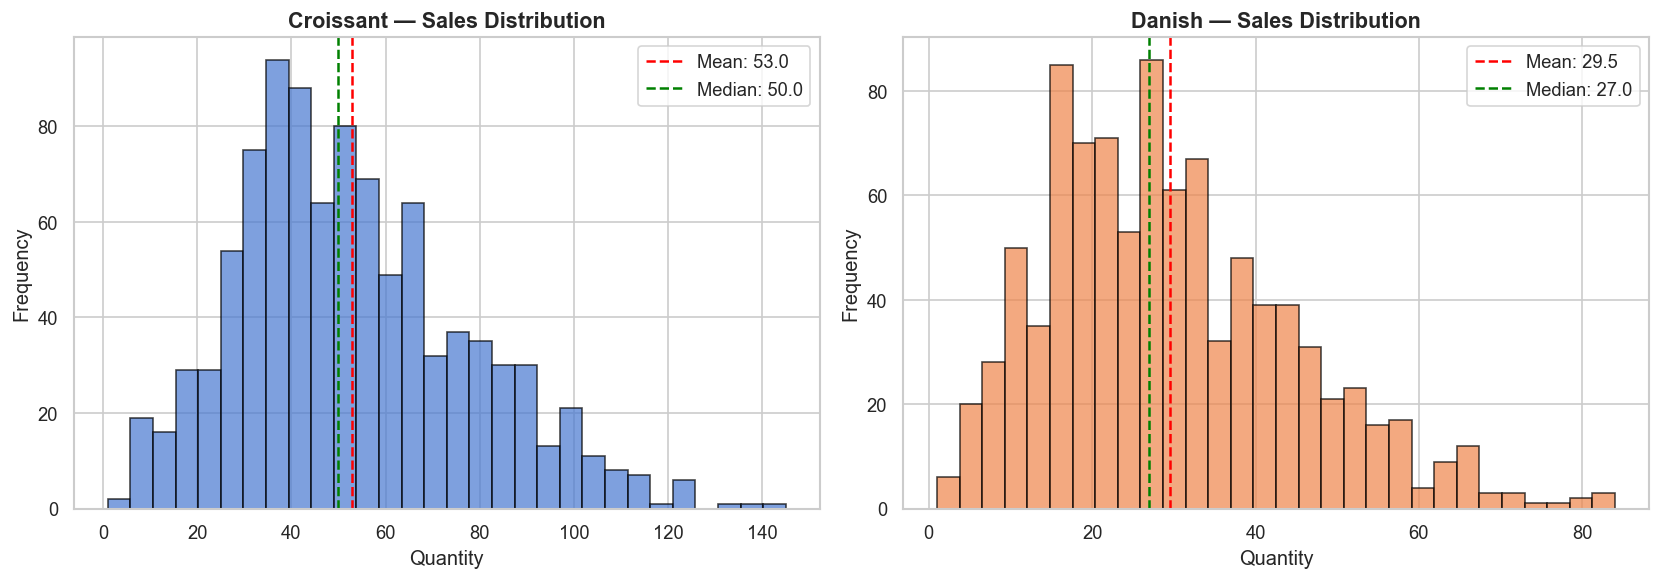

Croissant skewness: 0.590 (right-skewed)
Danish skewness: 0.714 (right-skewed)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, item in enumerate(['Croissant', 'Danish']):
    item_df = df[df['item'] == item]
    axes[idx].hist(item_df['quantity'], bins=30, edgecolor='black', alpha=0.7, color=sns.color_palette()[idx])
    mean_val = item_df['quantity'].mean()
    median_val = item_df['quantity'].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.1f}')
    axes[idx].set_title(f'{item} — Sales Distribution', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Quantity')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../reports/figures/eda_distributions.png', bbox_inches='tight')
plt.show()

# Skewness
for item in ['Croissant', 'Danish']:
    skew = df[df['item'] == item]['quantity'].skew()
    print(f"{item} skewness: {skew:.3f} {'(right-skewed)' if skew > 0.5 else '(approximately symmetric)' if abs(skew) < 0.5 else '(left-skewed)'}")

## Step 4: Data Quality Checks

### 4a. Missing Dates

In [12]:
# Identify operational days from the data
all_dates = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')
actual_dates = df['date'].dt.normalize().unique()

missing_dates = sorted(set(all_dates) - set(actual_dates))
print(f"Total calendar days in range: {len(all_dates)}")
print(f"Days with data: {len(actual_dates)}")
print(f"Missing dates: {len(missing_dates)}")

# Group missing dates by day of week
if missing_dates:
    missing_df = pd.DataFrame({'date': missing_dates})
    missing_df['day_name'] = missing_df['date'].dt.day_name()
    print(f"\nMissing dates by day of week:")
    display(missing_df['day_name'].value_counts().reindex(day_order).dropna())
    
    print(f"\nSample missing dates (first 20):")
    for d in missing_dates[:20]:
        print(f"  {d.date()} ({d.day_name()})")

Total calendar days in range: 1632
Days with data: 972
Missing dates: 660

Missing dates by day of week:


day_name
Monday       212
Tuesday      207
Wednesday    154
Thursday      50
Friday        15
Saturday       9
Sunday        13
Name: count, dtype: int64


Sample missing dates (first 20):
  2021-05-17 (Monday)
  2021-05-24 (Monday)
  2021-05-31 (Monday)
  2021-06-07 (Monday)
  2021-06-14 (Monday)
  2021-06-21 (Monday)
  2021-06-28 (Monday)
  2021-07-04 (Sunday)
  2021-07-05 (Monday)
  2021-07-12 (Monday)
  2021-07-19 (Monday)
  2021-07-26 (Monday)
  2021-07-27 (Tuesday)
  2021-08-02 (Monday)
  2021-08-09 (Monday)
  2021-08-16 (Monday)
  2021-08-23 (Monday)
  2021-08-30 (Monday)
  2021-09-06 (Monday)
  2021-09-13 (Monday)


In [13]:
# Check per-product: do both products appear on every operational day?
dates_per_product = df.groupby('item')['date'].apply(set)
croissant_dates = dates_per_product.get('Croissant', set())
danish_dates = dates_per_product.get('Danish', set())

only_croissant = croissant_dates - danish_dates
only_danish = danish_dates - croissant_dates

print(f"Days with Croissant but not Danish: {len(only_croissant)}")
if only_croissant:
    for d in sorted(only_croissant)[:10]:
        print(f"  {d.date()} ({d.day_name()})")

print(f"\nDays with Danish but not Croissant: {len(only_danish)}")
if only_danish:
    for d in sorted(only_danish)[:10]:
        print(f"  {d.date()} ({d.day_name()})")

Days with Croissant but not Danish: 36
  2021-07-06 (Tuesday)
  2021-10-25 (Monday)
  2022-05-31 (Tuesday)
  2022-06-30 (Thursday)
  2022-08-11 (Thursday)
  2022-08-26 (Friday)
  2022-08-27 (Saturday)
  2023-04-09 (Sunday)
  2023-05-10 (Wednesday)
  2023-11-11 (Saturday)

Days with Danish but not Croissant: 6
  2021-09-07 (Tuesday)
  2024-04-08 (Monday)
  2024-10-21 (Monday)
  2025-04-17 (Thursday)
  2025-06-29 (Sunday)
  2025-09-14 (Sunday)


### 4b. Outliers

In [14]:
print("Outlier detection using IQR method (1.5x IQR):\n")

for item in ['Croissant', 'Danish']:
    item_df = df[df['item'] == item]
    q1 = item_df['quantity'].quantile(0.25)
    q3 = item_df['quantity'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = item_df[(item_df['quantity'] < lower) | (item_df['quantity'] > upper)]
    
    print(f"{item}:")
    print(f"  IQR: {iqr}, Bounds: [{lower:.1f}, {upper:.1f}]")
    print(f"  Outliers: {len(outliers)} ({len(outliers)/len(item_df)*100:.1f}% of data)")
    if len(outliers) > 0:
        print(f"  Top outliers:")
        display(outliers.nlargest(10, 'quantity')[['date', 'item', 'quantity', 'day_name']])
    print()

Outlier detection using IQR method (1.5x IQR):

Croissant:
  IQR: 33.0, Bounds: [-14.5, 117.5]
  Outliers: 10 (1.0% of data)
  Top outliers:


,date,item,quantity,day_name
588,2022-06-11,Croissant,145,Saturday
756,2022-11-05,Croissant,136,Saturday
143,2021-08-07,Croissant,133,Saturday
167,2021-08-21,Croissant,125,Saturday
617,2022-07-02,Croissant,125,Saturday
559,2022-05-21,Croissant,124,Saturday
653,2022-07-31,Croissant,124,Sunday
598,2022-06-18,Croissant,122,Saturday
357,2021-12-24,Croissant,121,Friday
641,2022-07-22,Croissant,118,Friday



Danish:
  IQR: 21.0, Bounds: [-13.5, 70.5]
  Outliers: 10 (1.1% of data)
  Top outliers:


,date,item,quantity,day_name
1051,2023-07-21,Danish,84,Friday
1383,2024-07-06,Danish,84,Saturday
1063,2023-07-29,Danish,82,Saturday
1129,2023-09-23,Danish,81,Saturday
1403,2024-07-20,Danish,80,Saturday
318,2021-11-24,Danish,77,Wednesday
1095,2023-08-20,Danish,74,Sunday
589,2022-06-11,Danish,71,Saturday
1085,2023-08-13,Danish,71,Sunday
1413,2024-07-27,Danish,71,Saturday


### 4c. Duplicates & Zero/Negative Values

In [15]:
# Duplicates
dupes = df[df.duplicated(subset=['date', 'item'], keep=False)]
print(f"Duplicate (date, item) rows: {len(dupes)}")
if len(dupes) > 0:
    display(dupes.head(10))

# Zero or negative
zeros = df[df['quantity'] == 0]
negatives = df[df['quantity'] < 0]
print(f"\nZero quantity rows: {len(zeros)}")
print(f"Negative quantity rows: {len(negatives)}")
if len(zeros) > 0:
    print("\nZero quantity entries:")
    display(zeros)

Duplicate (date, item) rows: 0

Zero quantity rows: 0
Negative quantity rows: 0


### 4d. Gaps Visualization

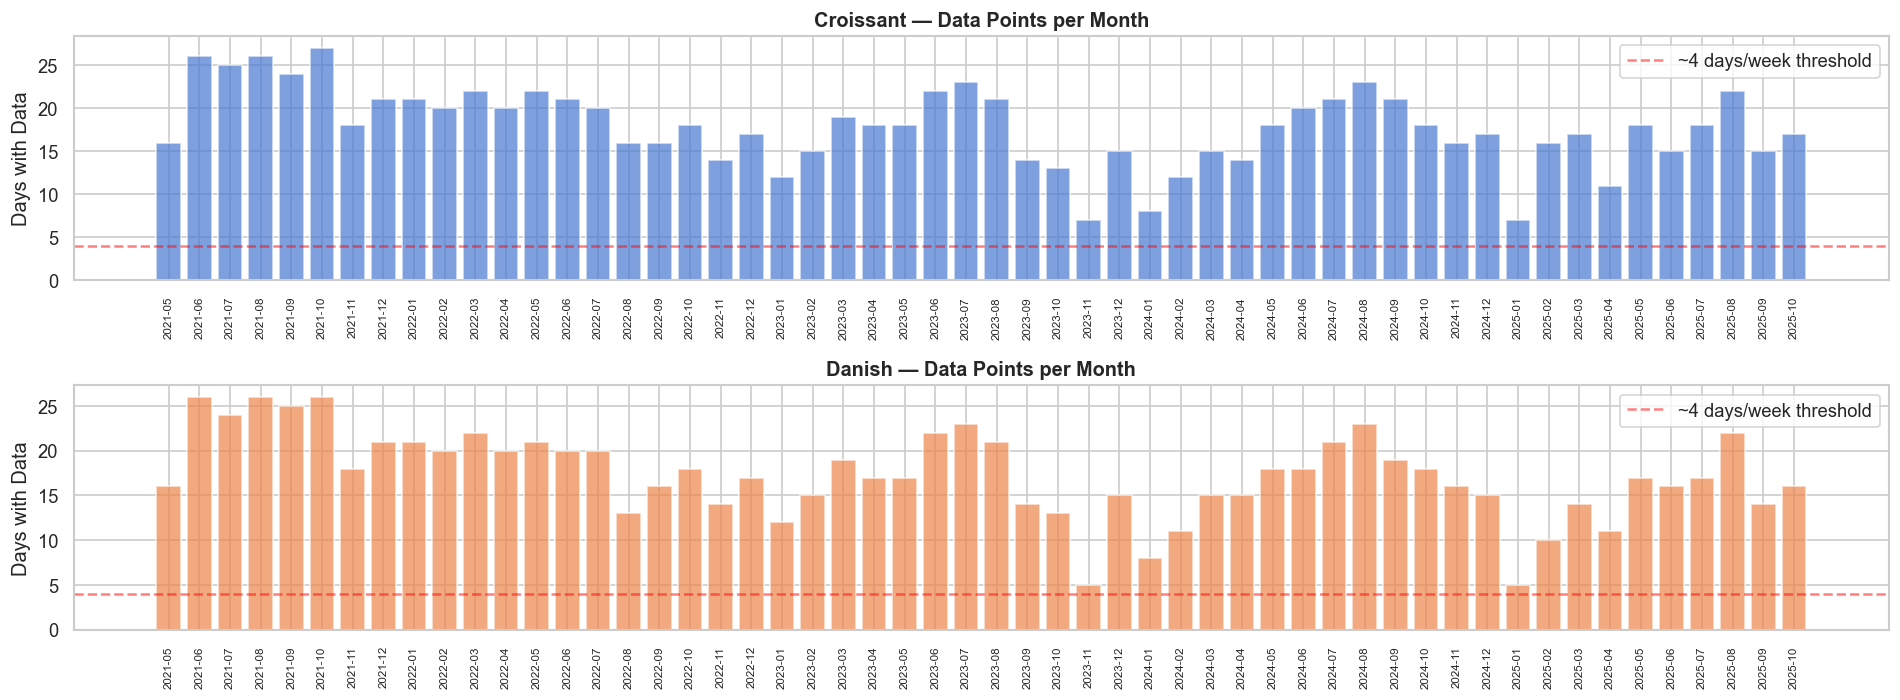

In [16]:
# Visualize data completeness as a heatmap by month/year
df['year_month'] = df['date'].dt.to_period('M')

completeness = df.groupby(['item', 'year_month']).size().reset_index(name='days_with_data')

fig, axes = plt.subplots(2, 1, figsize=(16, 6))

for idx, item in enumerate(['Croissant', 'Danish']):
    item_comp = completeness[completeness['item'] == item].copy()
    item_comp['year_month_str'] = item_comp['year_month'].astype(str)
    axes[idx].bar(item_comp['year_month_str'], item_comp['days_with_data'], 
                  color=sns.color_palette()[idx], alpha=0.7)
    axes[idx].set_title(f'{item} — Data Points per Month', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Days with Data')
    axes[idx].tick_params(axis='x', rotation=90, labelsize=7)
    axes[idx].axhline(y=4, color='red', linestyle='--', alpha=0.5, label='~4 days/week threshold')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../reports/figures/eda_data_completeness.png', bbox_inches='tight')
plt.show()

## Step 5: Deep Dives

### 5a. Day-of-Week x Month Heatmap

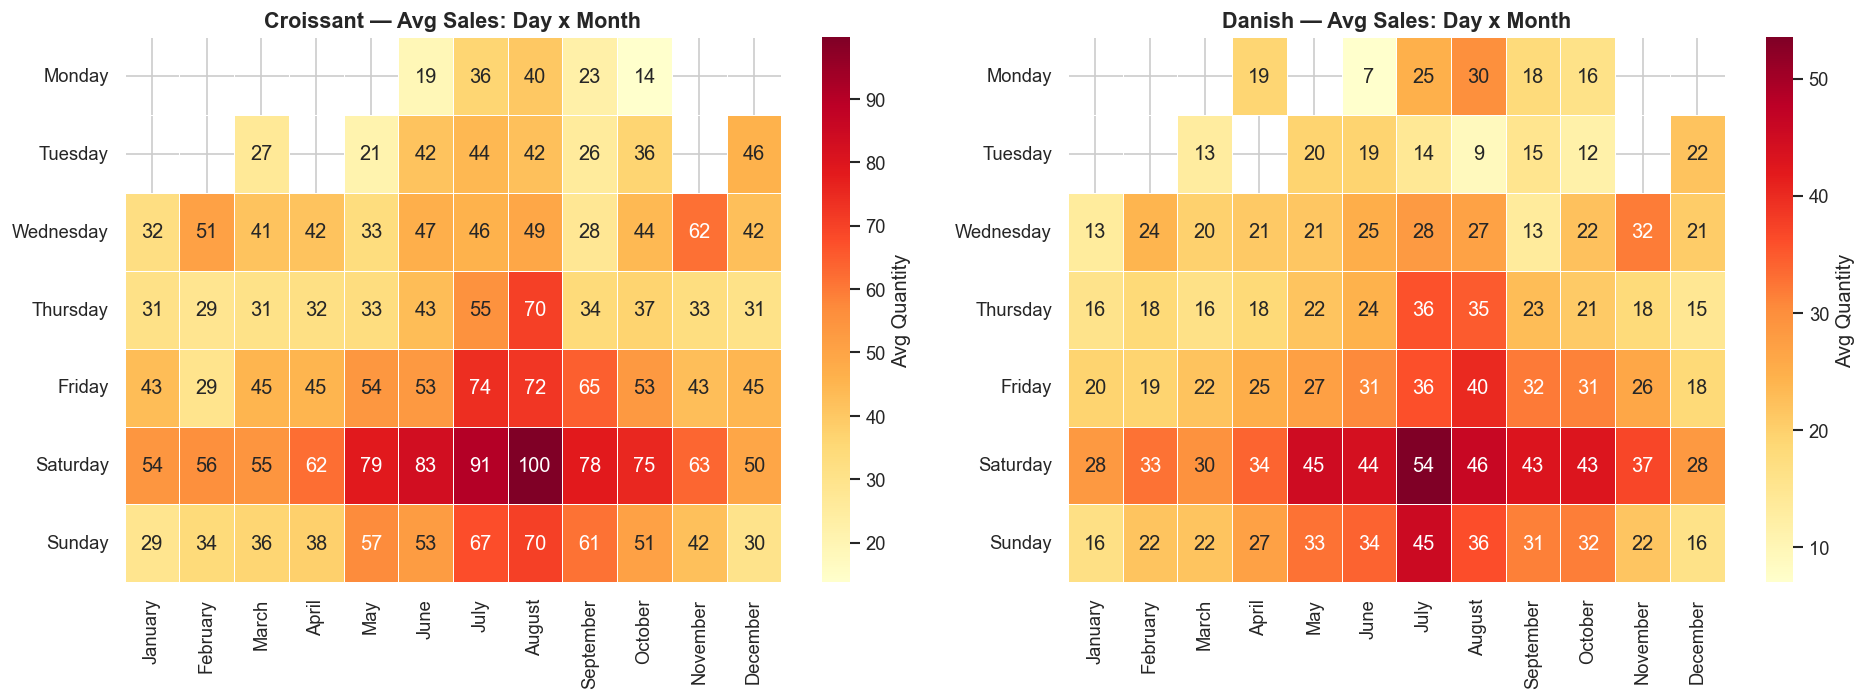

Does the day-of-week pattern stay consistent across months, or does it shift seasonally?


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, item in enumerate(['Croissant', 'Danish']):
    item_df = df[df['item'] == item]
    heatmap_data = item_df.pivot_table(values='quantity', index='day_name', columns='month_name',
                                        aggfunc='mean')
    heatmap_data = heatmap_data.reindex(index=day_order, columns=month_order)
    sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[idx],
                linewidths=0.5, cbar_kws={'label': 'Avg Quantity'})
    axes[idx].set_title(f'{item} — Avg Sales: Day x Month', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/figures/eda_dow_month_heatmap.png', bbox_inches='tight')
plt.show()

print("Does the day-of-week pattern stay consistent across months, or does it shift seasonally?")

### 5b. Product Correlation

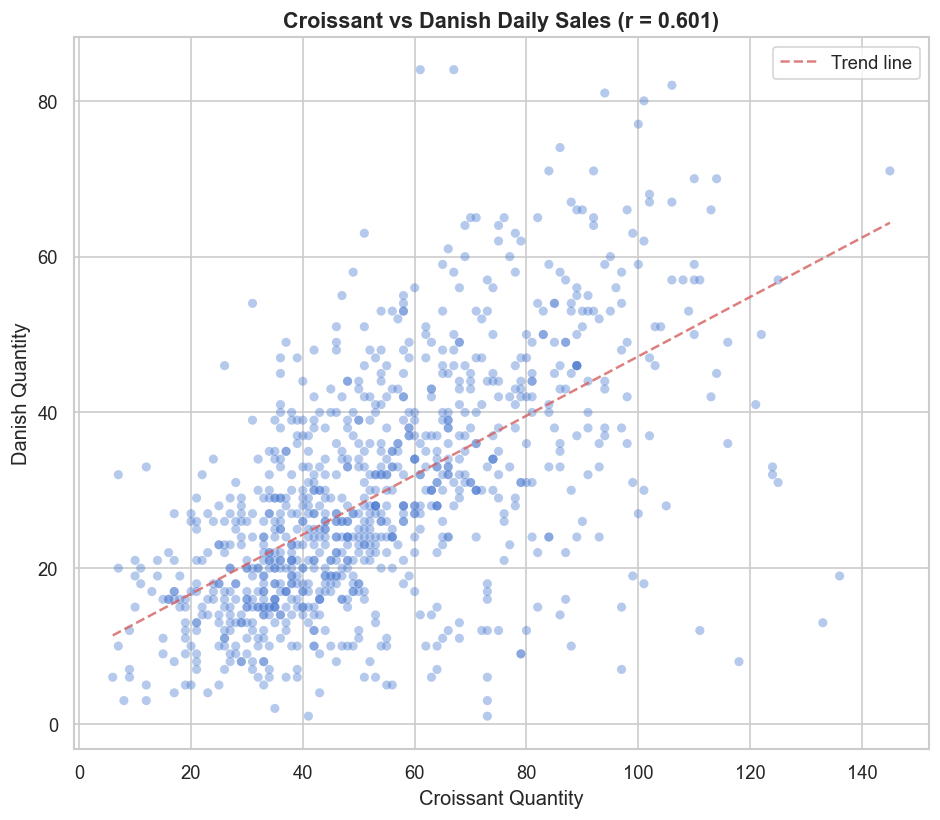


Pearson correlation: 0.601
If products move together, they likely share the same demand drivers (foot traffic, day of week, etc.)


In [18]:
# Pivot to get Croissant and Danish as columns for the same dates
pivot = df.pivot_table(values='quantity', index='date', columns='item')
pivot = pivot.dropna()

corr = pivot['Croissant'].corr(pivot['Danish'])

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(pivot['Croissant'], pivot['Danish'], alpha=0.4, edgecolor='none', s=30)
ax.set_xlabel('Croissant Quantity', fontsize=12)
ax.set_ylabel('Danish Quantity', fontsize=12)
ax.set_title(f'Croissant vs Danish Daily Sales (r = {corr:.3f})', fontsize=13, fontweight='bold')

# Regression line
z = np.polyfit(pivot['Croissant'], pivot['Danish'], 1)
p = np.poly1d(z)
x_line = np.linspace(pivot['Croissant'].min(), pivot['Croissant'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.8, label=f'Trend line')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/eda_product_correlation.png', bbox_inches='tight')
plt.show()

print(f"\nPearson correlation: {corr:.3f}")
print("If products move together, they likely share the same demand drivers (foot traffic, day of week, etc.)")

### 5c. Rolling Trend & Volatility

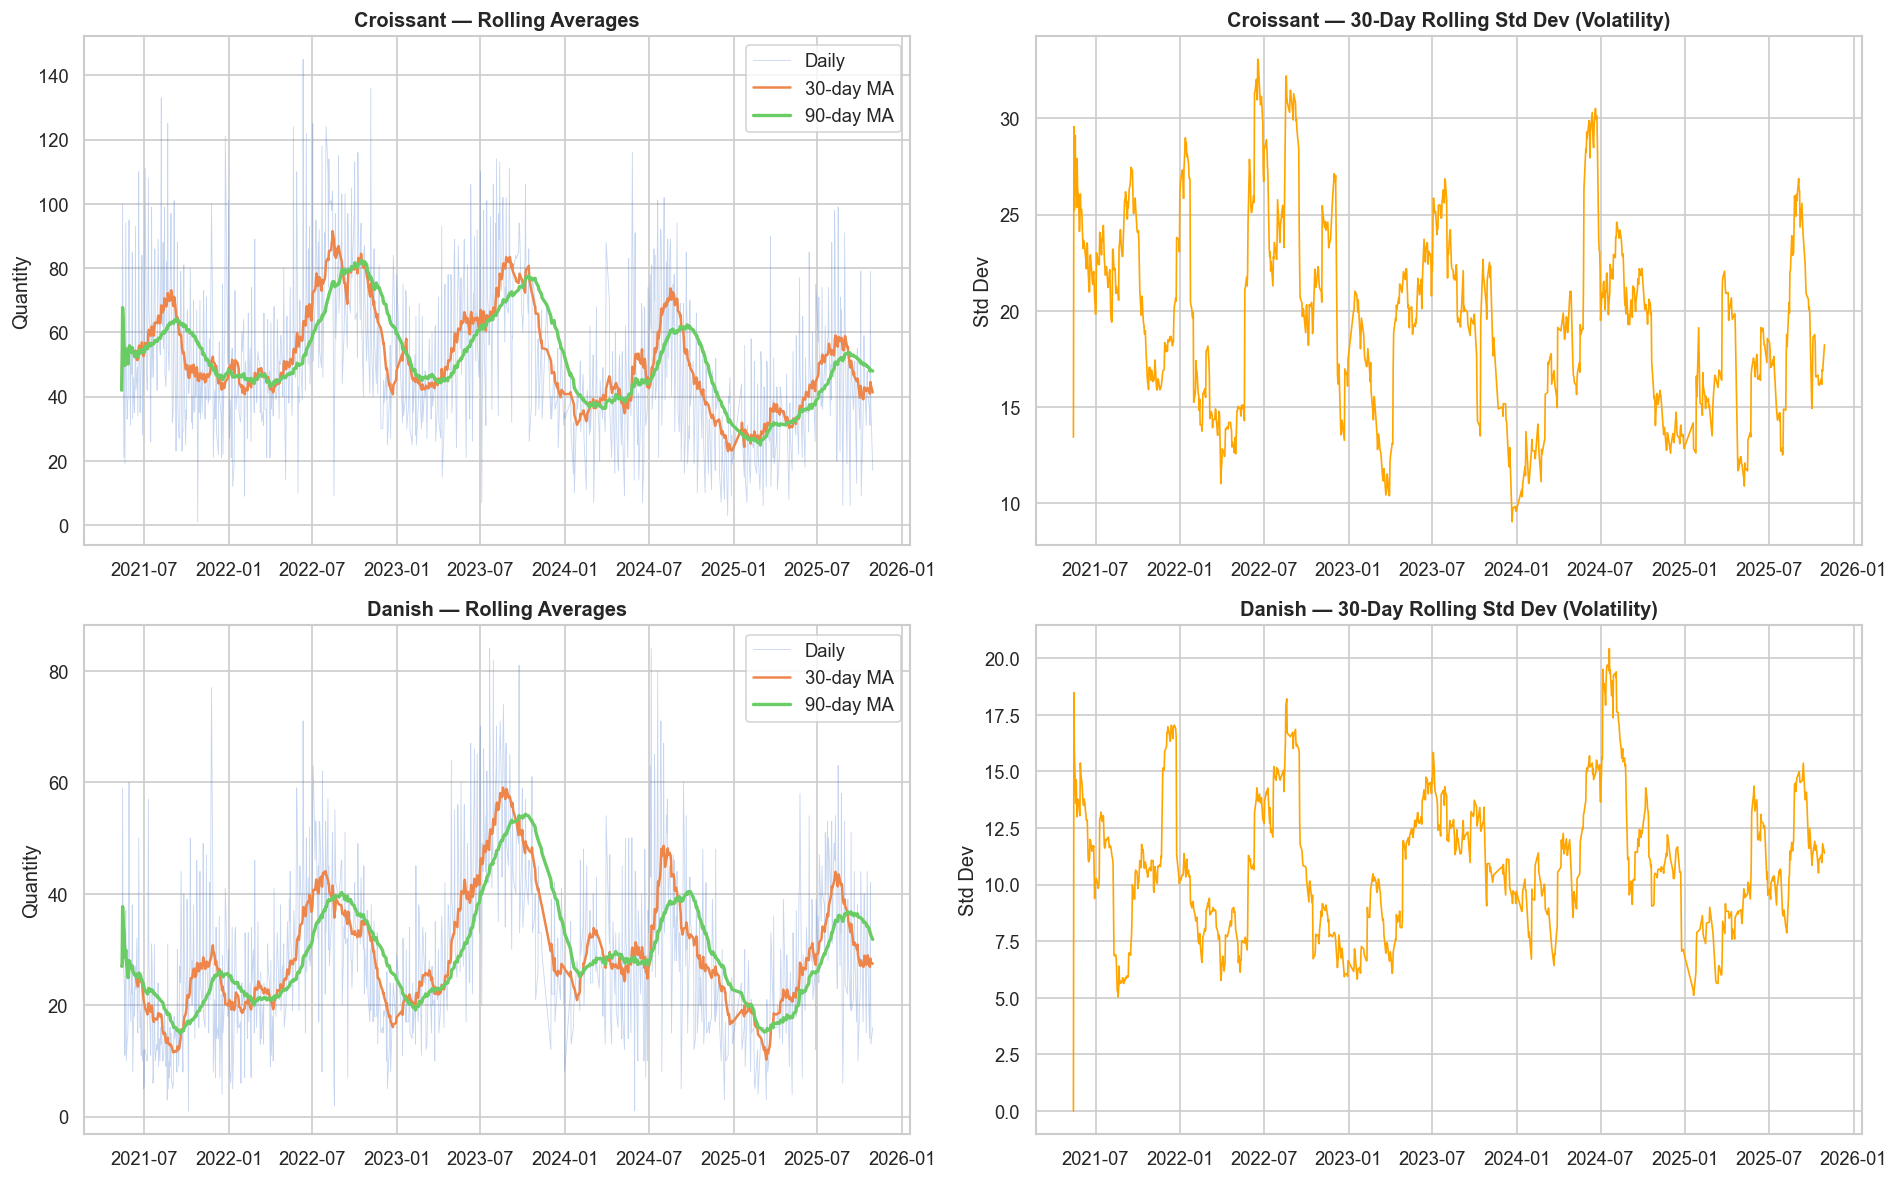

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, item in enumerate(['Croissant', 'Danish']):
    item_df = df[df['item'] == item].set_index('date').sort_index()
    
    # Rolling mean
    roll_30 = item_df['quantity'].rolling('30D').mean()
    roll_90 = item_df['quantity'].rolling('90D').mean()
    
    axes[idx][0].plot(item_df.index, item_df['quantity'], alpha=0.3, linewidth=0.5, label='Daily')
    axes[idx][0].plot(roll_30.index, roll_30.values, linewidth=1.5, label='30-day MA')
    axes[idx][0].plot(roll_90.index, roll_90.values, linewidth=2, label='90-day MA')
    axes[idx][0].set_title(f'{item} — Rolling Averages', fontweight='bold')
    axes[idx][0].set_ylabel('Quantity')
    axes[idx][0].legend(loc='upper right')
    
    # Rolling std (volatility)
    roll_std = item_df['quantity'].rolling('30D').std()
    axes[idx][1].plot(roll_std.index, roll_std.values, color='orange', linewidth=1)
    axes[idx][1].set_title(f'{item} — 30-Day Rolling Std Dev (Volatility)', fontweight='bold')
    axes[idx][1].set_ylabel('Std Dev')

plt.tight_layout()
plt.savefig('../reports/figures/eda_rolling_trend_volatility.png', bbox_inches='tight')
plt.show()

## Step 6: Findings Summary

Run this cell after reviewing all the plots above. Fill in your observations!

In [20]:
print("="*70)
print("EDA FINDINGS SUMMARY")
print("="*70)

print(f"""
DATA OVERVIEW
  Products: Croissant, Danish
  Date range: {df['date'].min().date()} to {df['date'].max().date()}
  Total records: {len(df)}
  Records per product: ~{len(df)//2}

KEY STATISTICS
""")
display(summary)

print(f"""
PATTERNS IDENTIFIED
  1. Day-of-week: [Review the boxplots — which days peak?]
  2. Seasonality:  [Review monthly plots — any seasonal wave?]
  3. Trend:        [Review YoY — growing, declining, or flat?]
  4. Correlation:  Croissant-Danish r = {corr:.3f}

DATA QUALITY
  Missing dates: {len(missing_dates)}
  Duplicates: {len(dupes)}
  Zero values: {len(zeros)}
  Negative values: {len(negatives)}

IMPLICATIONS FOR MODELING
  - Day-of-week should be a primary feature
  - Seasonal features (month, week_of_year) likely important
  - Consider whether to model products jointly or separately
  - Handle missing dates according to operational schedule
""")

EDA FINDINGS SUMMARY

DATA OVERVIEW
  Products: Croissant, Danish
  Date range: 2021-05-13 to 2025-10-30
  Total records: 1902
  Records per product: ~951

KEY STATISTICS



,count,mean,median,std,min,q25,q75,max,cv,iqr
item,,,,,,,,,,
Croissant,966,52.95,50.0,24.53,1,35.0,68.0,145,0.463,33.0
Danish,936,29.55,27.0,15.17,1,18.0,39.0,84,0.513,21.0



PATTERNS IDENTIFIED
  1. Day-of-week: [Review the boxplots — which days peak?]
  2. Seasonality:  [Review monthly plots — any seasonal wave?]
  3. Trend:        [Review YoY — growing, declining, or flat?]
  4. Correlation:  Croissant-Danish r = 0.601

DATA QUALITY
  Missing dates: 660
  Duplicates: 0
  Zero values: 0
  Negative values: 0

IMPLICATIONS FOR MODELING
  - Day-of-week should be a primary feature
  - Seasonal features (month, week_of_year) likely important
  - Consider whether to model products jointly or separately
  - Handle missing dates according to operational schedule

